In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix, RocCurveDisplay)
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/features.csv')
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn_binary'].mean():.3f}")
df.head()

Shape: (7043, 28)
Churn rate: 0.265


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaymentMethod_encoded,recency_risk,service_count,monetary_value,monthly_to_total_ratio,charge_per_month,clv_proxy,is_high_value,contract_stability,digital_engagement
0,0,1,0,1,0,0,0,1,0,0,...,0,0.500000,1,29.85,0.967585,14.925000,14.925000,0,0,1
1,0,0,0,34,1,0,1,0,1,0,...,1,0.028571,3,1889.50,0.030124,1.627143,1835.514286,0,34,0
2,0,0,0,2,1,0,1,1,0,0,...,1,0.333333,3,108.15,0.493358,17.950000,72.100000,0,0,1
3,0,0,0,45,0,0,1,0,1,1,...,2,0.021739,3,1840.75,0.022967,0.919565,1800.733696,0,45,1
4,0,0,0,2,1,0,0,0,0,0,...,0,0.333333,1,151.65,0.463151,23.566667,101.100000,0,0,1


In [2]:
TARGET = 'Churn_binary'
DROP_COLS = ['Churn_binary']

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Churn rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}  | Churn rate: {y_test.mean():.3f}")
print(f"\nFeatures: {X.columns.tolist()}")

Train: (5634, 27) | Churn rate: 0.265
Test:  (1409, 27)  | Churn rate: 0.265

Features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_encoded', 'InternetService_encoded', 'PaymentMethod_encoded', 'recency_risk', 'service_count', 'monetary_value', 'monthly_to_total_ratio', 'charge_per_month', 'clv_proxy', 'is_high_value', 'contract_stability', 'digital_engagement']


In [3]:
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('churn-prediction')

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'random_state': 42,
    'verbose': -1,
}

with mlflow.start_run(run_name='lightgbm_baseline'):
    # Train
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

    callbacks = [lgb.early_stopping(50), lgb.log_evaluation(100)]

    model = lgb.train(
        params,
        train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=callbacks,
    )

    # Predict
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Log vào MLflow
    mlflow.log_params(params)
    mlflow.log_metrics({
        'auc_roc': auc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
    })
    mlflow.lightgbm.log_model(model, 'lightgbm_model')

    print(f"=== MODEL PERFORMANCE ===")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"\nMLflow run logged ✅")

2026/03/09 14:50:25 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's auc: 0.8445


2026/03/09 14:51:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== MODEL PERFORMANCE ===
AUC-ROC:   0.8445
F1 Score:  0.6365
Precision: 0.5742
Recall:    0.7139

MLflow run logged ✅
🏃 View run lightgbm_baseline at: http://localhost:5000/#/experiments/1/runs/415ae57bdb224337a374e60eafa5ed6c
🧪 View experiment at: http://localhost:5000/#/experiments/1


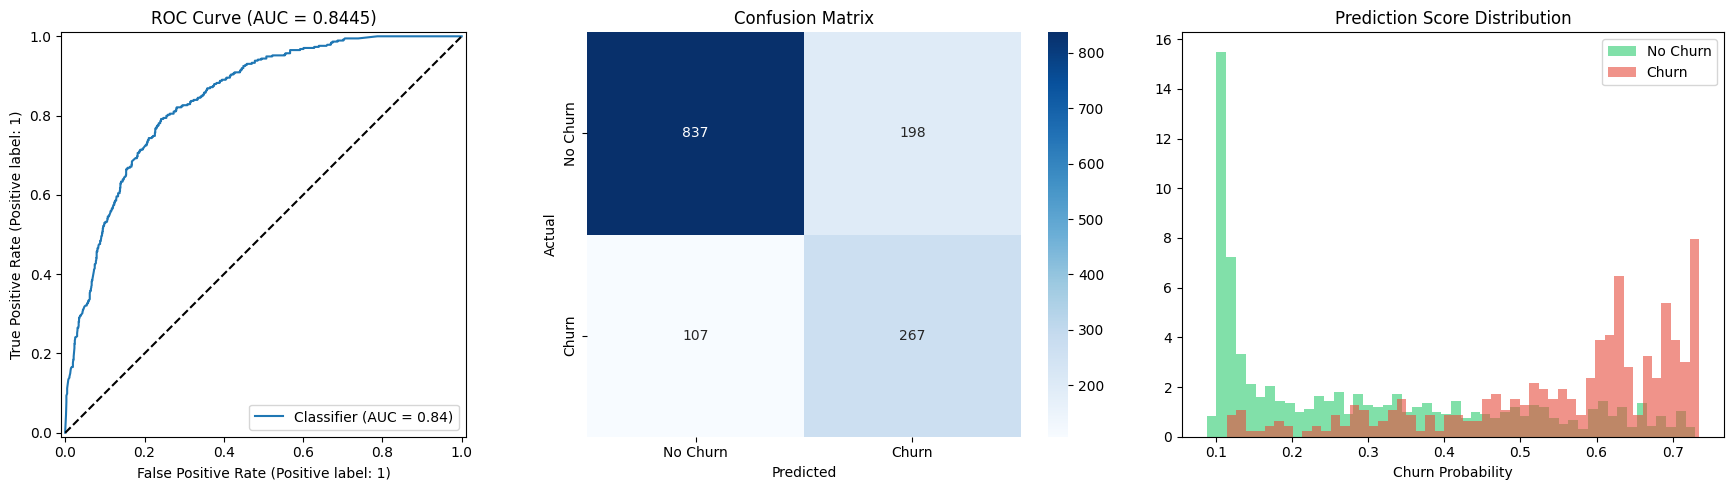

              precision    recall  f1-score   support

    No Churn       0.89      0.81      0.85      1035
       Churn       0.57      0.71      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title(f'ROC Curve (AUC = {auc:.4f})')
axes[0].plot([0,1], [0,1], 'k--')

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# 3. Prediction distribution
axes[2].hist(y_pred_proba[y_test==0], bins=50, alpha=0.6,
             color='#2ECC71', label='No Churn', density=True)
axes[2].hist(y_pred_proba[y_test==1], bins=50, alpha=0.6,
             color='#E74C3C', label='Churn', density=True)
axes[2].set_title('Prediction Score Distribution')
axes[2].set_xlabel('Churn Probability')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/processed/model_evaluation.png', dpi=150)
plt.show()

print(classification_report(y_test, y_pred,
                             target_names=['No Churn', 'Churn']))

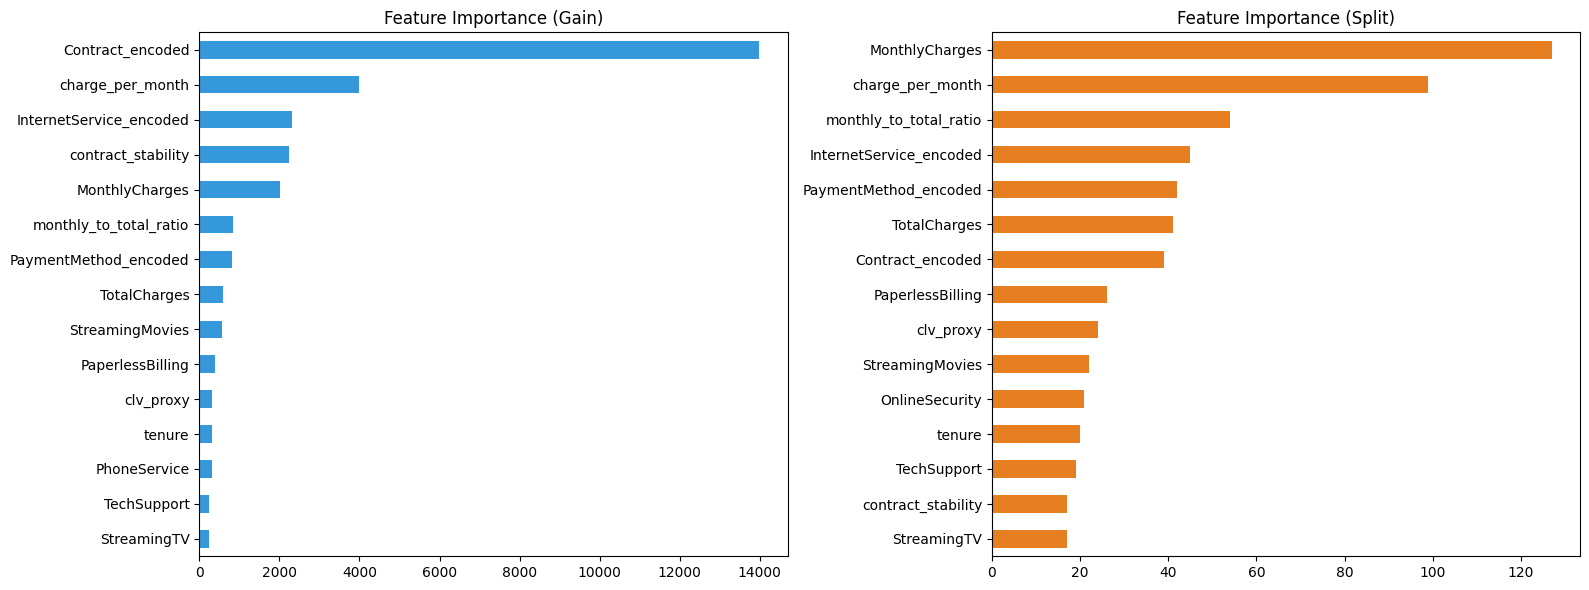

Top 10 features by gain:
Contract_encoded           13993.742143
charge_per_month            3993.100971
InternetService_encoded     2325.029101
contract_stability          2245.439496
MonthlyCharges              2021.131345
monthly_to_total_ratio       842.831439
PaymentMethod_encoded        803.582150
TotalCharges                 587.318350
StreamingMovies              577.175441
PaperlessBilling             383.492929
dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gain importance
importance_gain = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=X.columns
).sort_values(ascending=True).tail(15)

importance_gain.plot(kind='barh', ax=axes[0], color='#3498DB')
axes[0].set_title('Feature Importance (Gain)')

# Split importance
importance_split = pd.Series(
    model.feature_importance(importance_type='split'),
    index=X.columns
).sort_values(ascending=True).tail(15)

importance_split.plot(kind='barh', ax=axes[1], color='#E67E22')
axes[1].set_title('Feature Importance (Split)')

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

# Top 10 features
print("Top 10 features by gain:")
print(importance_gain.sort_values(ascending=False).head(10))

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_clf = lgb.LGBMClassifier(**{k: v for k, v in params.items()
                                  if k != 'metric'}, n_estimators=300)

cv_scores = cross_val_score(lgb_clf, X, y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)

print(f"=== 5-FOLD CROSS VALIDATION ===")
print(f"AUC scores: {cv_scores.round(4)}")
print(f"Mean AUC:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

with mlflow.start_run(run_name='lightgbm_cv', nested=True):
    mlflow.log_metric('cv_mean_auc', cv_scores.mean())
    mlflow.log_metric('cv_std_auc', cv_scores.std())

=== 5-FOLD CROSS VALIDATION ===
AUC scores: [0.8473 0.8259 0.8382 0.8164 0.8298]
Mean AUC:   0.8315 (+/- 0.0106)
🏃 View run lightgbm_cv at: http://localhost:5000/#/experiments/1/runs/fadaf10b8aff4eb1841b086be9f3fa27
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [7]:
import joblib, os
os.makedirs('../data/processed/models', exist_ok=True)

model.save_model('../data/processed/models/lgbm_churn.txt')

# Save feature list
import json
with open('../data/processed/models/feature_cols.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print("Model saved locally ✅")
print(f"MLflow UI: http://localhost:5000")

Model saved locally ✅
MLflow UI: http://localhost:5000


In [8]:
# Default threshold 0.5 chưa chắc tối ưu
# Tìm threshold tối ưu cho F1

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[f1_scores.argmax()]
best_f1 = f1_scores.max()

print(f"Default threshold (0.5):")
print(f"  F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

y_pred_tuned = (y_pred_proba > best_threshold).astype(int)
print(f"\nOptimal threshold ({best_threshold:.3f}):")
print(f"  F1: {f1_score(y_test, y_pred_tuned):.4f} | "
      f"Precision: {precision_score(y_test, y_pred_tuned):.4f} | "
      f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")

# Log threshold vào MLflow
with mlflow.start_run(run_name='lightgbm_threshold_tuning'):
    mlflow.log_metric('optimal_threshold', best_threshold)
    mlflow.log_metric('best_f1', best_f1)

Default threshold (0.5):
  F1: 0.6365 | Precision: 0.5742 | Recall: 0.7139

Optimal threshold (0.446):
  F1: 0.6420 | Precision: 0.5413 | Recall: 0.7888
🏃 View run lightgbm_threshold_tuning at: http://localhost:5000/#/experiments/1/runs/a03207b0f2d743498982db120175a55b
🧪 View experiment at: http://localhost:5000/#/experiments/1
